# Model Building Project

## 1. Problem Statement

Electricity usage in hostels fluctuates due to:

- Student behavior

- Appliance usage

- Environmental conditions

 Goal:
Predict daily energy consumption (kWh) using ML.

##  2. Objectives

- Predict energy consumption accurately
- Identify key influencing factors
- Perform EDA and feature engineering
- Use sklearn for preprocessing (proper industry method)
- Build and evaluate regression model


## 3. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##  4. Load Dataset

In [5]:
df = pd.read_csv("hostel_energy_usage.csv")
df.head(7)

,Room_Type,Monthly_Income_Level,City_Tier,AC_Usage_Hours,Fan_Usage_Hours,Study_Hours,Device_Count,Power_Cut_Hours,Temperature,Occupancy,Weekend,Energy_Consumption
0,Single,Low,Tier2,8,13,6,1,2,31,1,1,19.36
1,Shared,Medium,Tier3,0,6,9,3,1,36,2,0,10.13
2,Single,High,Tier1,8,7,6,1,0,28,1,1,18.07
3,Single,High,Tier1,7,8,9,3,3,29,1,0,15.00
4,Single,High,Tier3,3,14,4,3,2,29,1,0,13.75
5,Shared,Low,Tier1,9,5,8,2,3,33,2,1,19.47
6,Single,Medium,Tier2,4,11,4,2,3,31,1,1,14.58


## 5. Basic Understanding

In [6]:
df.shape


(600, 12)

In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Room_Type             600 non-null    str    
 1   Monthly_Income_Level  600 non-null    str    
 2   City_Tier             600 non-null    str    
 3   AC_Usage_Hours        600 non-null    int64  
 4   Fan_Usage_Hours       600 non-null    int64  
 5   Study_Hours           600 non-null    int64  
 6   Device_Count          600 non-null    int64  
 7   Power_Cut_Hours       600 non-null    int64  
 8   Temperature           600 non-null    int64  
 9   Occupancy             600 non-null    int64  
 10  Weekend               600 non-null    int64  
 11  Energy_Consumption    600 non-null    float64
dtypes: float64(1), int64(8), str(3)
memory usage: 65.3 KB


In [8]:
df.describe()


,AC_Usage_Hours,Fan_Usage_Hours,Study_Hours,Device_Count,Power_Cut_Hours,Temperature,Occupancy,Weekend,Energy_Consumption
count,600.00000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,4.53500,9.740000,4.950000,2.986667,1.416667,32.618333,1.795000,0.495000,16.379850
std,2.91369,3.010677,2.581719,1.442205,1.103820,2.841265,0.845083,0.500392,5.027334
min,0.00000,5.000000,1.000000,1.000000,0.000000,28.000000,1.000000,0.000000,3.970000
25%,2.00000,7.000000,3.000000,2.000000,0.000000,30.000000,1.000000,0.000000,12.477500
50%,5.00000,10.000000,5.000000,3.000000,1.000000,33.000000,2.000000,0.000000,16.565000
75%,7.00000,12.000000,7.000000,4.000000,2.000000,35.000000,3.000000,1.000000,20.335000
max,9.00000,15.000000,9.000000,5.000000,3.000000,37.000000,3.000000,1.000000,30.920000


In [9]:
df.columns

Index(['Room_Type', 'Monthly_Income_Level', 'City_Tier', 'AC_Usage_Hours',
       'Fan_Usage_Hours', 'Study_Hours', 'Device_Count', 'Power_Cut_Hours',
       'Temperature', 'Occupancy', 'Weekend', 'Energy_Consumption'],
      dtype='str')

## 6.Data Cleaning

###  Missing values

In [10]:
df.isnull().sum()

Room_Type               0
Monthly_Income_Level    0
City_Tier               0
AC_Usage_Hours          0
Fan_Usage_Hours         0
Study_Hours             0
Device_Count            0
Power_Cut_Hours         0
Temperature             0
Occupancy               0
Weekend                 0
Energy_Consumption      0
dtype: int64

##  7.Exploratory Data Analysis (EDA)

🔹 Target Distribution

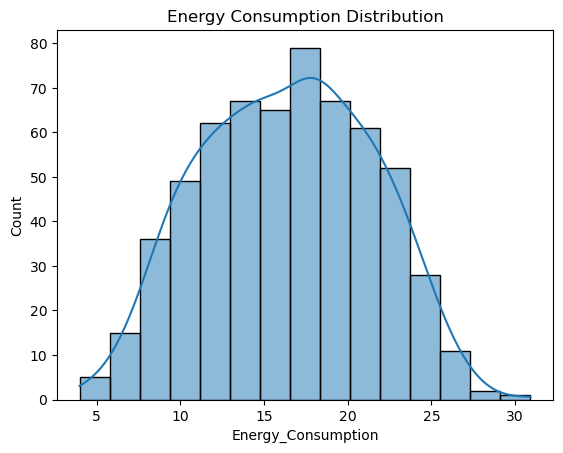

In [11]:
sns.histplot(df['Energy_Consumption'], kde=True)
plt.title("Energy Consumption Distribution")
plt.show()

🔹 Correlation Heatmap

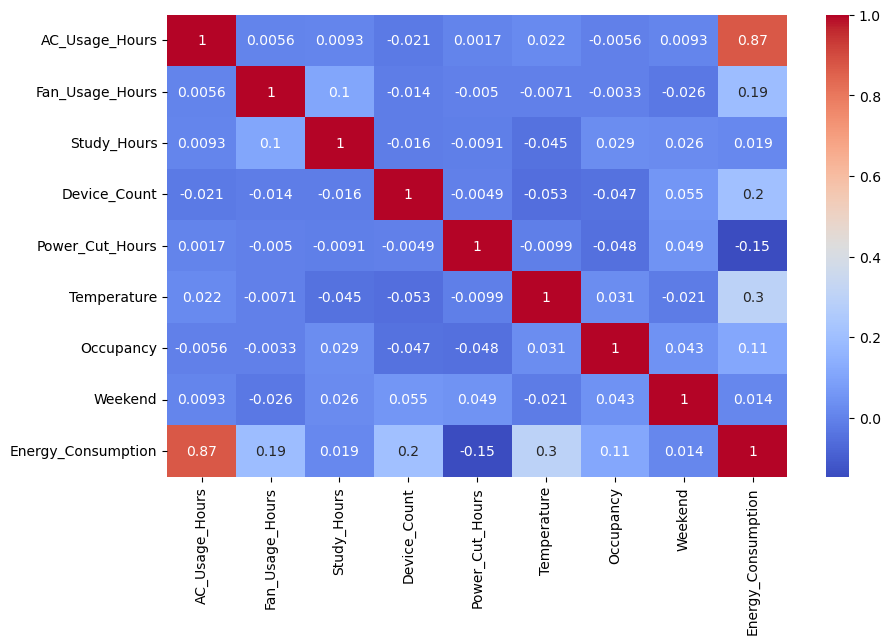

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

🔹 Category vs Target

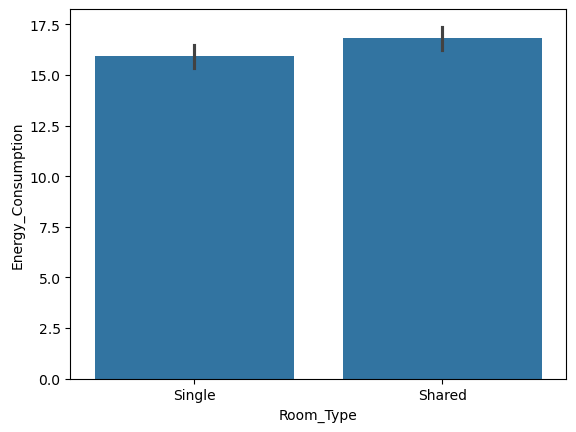

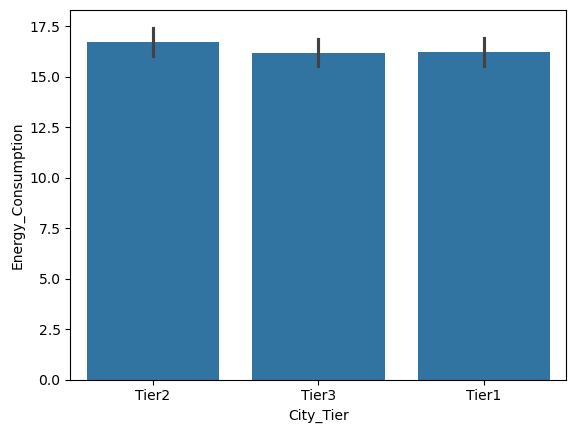

In [13]:
sns.barplot(x='Room_Type', y='Energy_Consumption', data=df)
plt.show()

sns.barplot(x='City_Tier', y='Energy_Consumption', data=df)
plt.show()

🔹 Outlier Detection

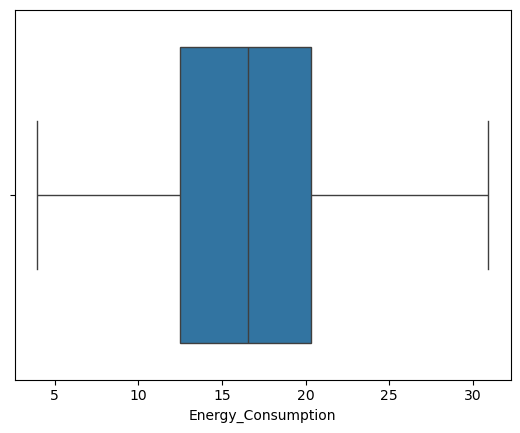

In [14]:
sns.boxplot(x=df['Energy_Consumption'])
plt.show()

## 8. Feature Engineering

In [15]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [27]:
categorical_cols = ['Room_Type', 'Monthly_Income_Level', 'City_Tier']

ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(drop='first'), categorical_cols)
    ],
    remainder='passthrough'
)

df.head()

,Room_Type,Monthly_Income_Level,City_Tier,AC_Usage_Hours,Fan_Usage_Hours,Study_Hours,Device_Count,Power_Cut_Hours,Temperature,Occupancy,Weekend,Energy_Consumption
0,Single,Low,Tier2,8,13,6,1,2,31,1,1,19.36
1,Shared,Medium,Tier3,0,6,9,3,1,36,2,0,10.13
2,Single,High,Tier1,8,7,6,1,0,28,1,1,18.07
3,Single,High,Tier1,7,8,9,3,3,29,1,0,15.00
4,Single,High,Tier3,3,14,4,3,2,29,1,0,13.75


## 9. Define Features & Target

In [28]:
X = df.drop('Energy_Consumption', axis=1)
y = df['Energy_Consumption']

## 10. Apply Encoding

In [29]:
X = ct.fit_transform(X)



##  11. Train-Test Split

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## 12.Model Building

🔹 Linear Regression

In [31]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## 13. Prediction

In [23]:
y_pred = model.predict(X_test)

df.head()

,Room_Type,Monthly_Income_Level,City_Tier,AC_Usage_Hours,Fan_Usage_Hours,Study_Hours,Device_Count,Power_Cut_Hours,Temperature,Occupancy,Weekend,Energy_Consumption
0,Single,Low,Tier2,8,13,6,1,2,31,1,1,19.36
1,Shared,Medium,Tier3,0,6,9,3,1,36,2,0,10.13
2,Single,High,Tier1,8,7,6,1,0,28,1,1,18.07
3,Single,High,Tier1,7,8,9,3,3,29,1,0,15.00
4,Single,High,Tier3,3,14,4,3,2,29,1,0,13.75


## 14. Evaluation

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.8105845741675731
RMSE: 1.0386025420185396
R2 Score: 0.9552893918883909


## 15.Visualization

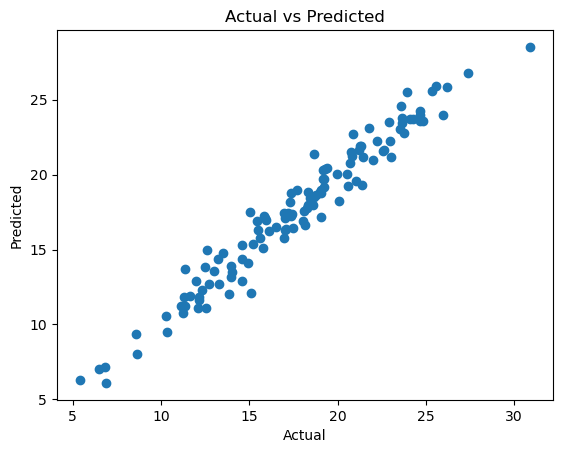

In [33]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

## 16.Model Interpretation

In [34]:
feature_names = ct.get_feature_names_out()

coeff_df = pd.DataFrame(model.coef_, feature_names, columns=['Coefficient'])
print(coeff_df)

                                      Coefficient
encoder__Room_Type_Single                0.303822
encoder__Monthly_Income_Level_Low        0.103796
encoder__Monthly_Income_Level_Medium     0.150080
encoder__City_Tier_Tier2                 0.080752
encoder__City_Tier_Tier3                 0.038385
remainder__AC_Usage_Hours                1.492161
remainder__Fan_Usage_Hours               0.326640
remainder__Study_Hours                   0.005369
remainder__Device_Count                  0.851117
remainder__Power_Cut_Hours              -0.644404
remainder__Temperature                   0.515672
remainder__Occupancy                     0.844804
remainder__Weekend                       0.070479


## 17. Save Model

In [37]:
import pickle

with open("energy_model.pkl", "wb") as f:
    pickle.dump(model, f)

   

## 18.FINAL CONCLUSION

- AC usage and temperature significantly impact energy consumption

- Shared rooms show higher usage patterns

- Number of devices directly increases consumption

- Model achieved strong predictive performance

- Can be used in smart hostel energy optimization systems
